# Exercise 2

This exercise is based on Chapter 7 of "Computational and Inferential Thinking: The Foundations of Data Science."

The material can be found in Jupyter notebooks in `GSP538/ds_book/chapters/7/`.

#### Notes on the textbook
- You will need to run each cell of the book to see the output. Be sure that you are in the `gsp538` environment.
- The textbook notebook is interactive. If you are working in the notebook and wonder, "what would happen if you changed ____?", you can just change it and rerun the cell. My recommendation is the copy (or comment out) the original code before changing it so you do not lose the original version. 
- My recommendation is to have the textbook chapter and this exercise both visible at the same time. You can click and drag the tab of one notebook so that it appears to the left (or right, above, below) of another notebook within the VS Code window.
- Click the Explorer icon in the upper-left of the VS Code window to collapse the file browser, making the notebook area larger.

#### Answer the following written questions

There is a blank Markdown cell after each question for your answer (double click in the blank cell to type your answer). Be sure to run your Markdown cells to format your answers.

1. Describe what a positive association looks like in a scatter plot and what this means about the relationship between the two variables. Do the same for negative association.

A **positive association** in a scatter plot means the points trend upward from left to right — as one variable increases, the other tends to increase as well. High values of one variable tend to go with high values of the other.

A **negative association** means the points trend downward from left to right — as one variable increases, the other tends to decrease. High values of one variable tend to go with low values of the other.

2. In your own words, what are data outliers? (Hint: you might want to go to Google to review a few definitions.)

Data outliers are observations that lie far outside the general range of the rest of the data. They are extreme values that are notably different from the majority of data points. For example, in a scatter plot, an outlier would appear as a point that is significantly separated from the main cluster of points. Outliers can result from measurement errors, data entry mistakes, or they may represent genuinely unusual cases.

3. Which type of plot would be best for each scenario (scatter, line, bar, histogram) and why? Note: Only give one answer for each scenario, and assume it would be one plot (not a series of plots or overlaid plots)). 

    a. Identify the relationship between counts of people by race/ethnic group in Arizona.

    b. Identify the relationship between number of sunny days and number of tourists for cities in the US.

    c. Identify how average income varies by age for Arizona residents.
    
    d. Identify how acreage of residential parcels varies in Coconino County.

a. **Bar chart** — Race/ethnic group is a categorical variable, and we want to compare counts across discrete categories. A bar chart displays the count (or frequency) for each category, making it easy to compare group sizes.

b. **Scatter plot** — Both sunny days and number of tourists are numerical variables, and we want to see the relationship between them for individual cities. A scatter plot shows one point per city, revealing whether there is an association.

c. **Line plot** — We are looking at how a numerical variable (average income) changes across an ordered numerical variable (age). A line plot connects the data points and makes it easy to see the trend over the age continuum.

d. **Histogram** — Acreage is a single numerical variable, and we want to see how residential parcel sizes are distributed (i.e., how many parcels fall into different size ranges). A histogram groups the continuous acreage values into bins and shows the distribution.

4. Why is the width of a bar in a bar chart simply a stylistic decision, but not so in a histogram?

In a bar chart, the categories on the axis have no inherent numerical scale or ordering, so the width of the bars is purely aesthetic — only the length/height matters because it is proportional to the count. In a histogram, the bars are drawn to scale on a number line and are contiguous (no gaps). The **area** of each bar (not just its height) is proportional to the frequency or percent of data in that bin. Since area = height × width, the width of the bin directly affects the visual interpretation of the data.

5. What does the area of each bar in a histogram represent when plotted with `density=True`?

When plotted with `density=True`, the area of each bar represents the proportion (or percent) of data entries that fall within that bin. The total area of all the bars sums to 1 (or 100%). The height of each bar is the density — calculated as the proportion of entries in the bin divided by the width of the bin.

6. You saw "interval notation" in this chapter. Describe the interval [3000, 6000) in words. Be sure to make clear whether or not 3000 and/or 6000 is included in the interval.

The interval [3000, 6000) includes all values from 3000 up to but not including 6000. The square bracket `[` means 3000 **is included** in the interval, and the parenthesis `)` means 6000 **is not included**. So a value of 3000 would be in this interval, but a value of 6000 would not.

7. What does it mean for a histogram to be "skewed to the right" or "skewed to the left"?

A histogram that is **skewed to the right** has most of its data concentrated on the left side, with a long tail extending to the right. This means there are a few unusually large values. A histogram that is **skewed to the left** has most of its data concentrated on the right side, with a long tail extending to the left, meaning there are a few unusually small values.

8. Look at the two figures and the discussion in the "Flat Tops and the Level of Detail" section of the `7_2_Visualizing_Numerical_Distributions.ipynb` notebook. How does this relate to the modifiable areal unit problem (MAUP) that you have seen in other GIS courses?

The "Flat Tops and Level of Detail" section shows that the flat top of a histogram bar hides internal variation within the bin — when a wide bin is split into narrower sub-bins, some sub-bars are taller and some shorter than the original bar's height. This relates directly to the Modifiable Areal Unit Problem (MAUP) in GIS: just as different spatial aggregation units (e.g., census tracts vs. counties) can yield different statistical results and hide local variation, different histogram bin widths can reveal or obscure patterns in the data. The choice of bin boundaries and widths changes the story the visualization tells, just as the choice of areal units changes the spatial patterns observed in GIS.

9. You can create plots in Python using the Pandas and Matplotlib packages. In your own words, why would you use one versus the other?

Pandas provides a convenient, user-friendly interface for creating common plots quickly with minimal code (e.g., `df.plot.scatter()`, `df.plot.hist()`). Internally, Pandas calls Matplotlib to render the plots. Matplotlib gives you much more fine-grained control over every aspect of the figure — labels, colors, axis ranges, layout, annotations, etc. — but requires more code and is less intuitive. In practice, you would start with Pandas for quick exploration and use Matplotlib when you need detailed customization.

#### The following questions require you to run Python code.

For these questions, you will be using a diabetes dataset.

> This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective is to predict based on diagnostic measurements whether a patient has diabetes. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

https://www.kaggle.com/datasets/mathchi/diabetes-data-set


Run the following cell to import the data.

In [1]:
import pandas as pd
import numpy as np

raw_data = pd.read_csv('data/Diabetes.csv')
raw_data = raw_data.rename(columns={'DiabetesPedigreeFunction':'DPF'})

10. Give a detailed explanation of the last line of code in the above cell. (Note: be sure to discuss all the data structures and variable types.)

`raw_data = raw_data.rename(columns={'DiabetesPedigreeFunction':'DPF'})` — This line uses the `rename` method on the `raw_data` DataFrame. The `columns` argument receives a dictionary where the key `'DiabetesPedigreeFunction'` is the current column name (a string) and the value `'DPF'` is the new column name (also a string). The method returns a new DataFrame with the renamed column, and that new DataFrame is assigned back to the variable `raw_data`, replacing the original. So `raw_data` is a DataFrame, `columns` is a keyword argument that takes a dictionary, and both the key and value in the dictionary are strings.

11. Apply the `info` method to `raw_data` (you have not seen the `info` method before, be sure to run it correctly). Based on this output: how many variables are you working with? How many records are there? Click the link in the description above for more info on the data (note: the `Outcome` column represents whether or not the person had diabetes). 

In [2]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    int64  
 2   BloodPressure  768 non-null    int64  
 3   SkinThickness  768 non-null    int64  
 4   Insulin        768 non-null    int64  
 5   BMI            768 non-null    float64
 6   DPF            768 non-null    float64
 7   Age            768 non-null    int64  
 8   Outcome        768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


There are 9 variables (columns) and 768 records (rows). The 9 variables are: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DPF (Diabetes Pedigree Function), Age, and Outcome. The data represents diagnostic measurements from 768 female patients of Pima Indian heritage, all at least 21 years old. The `Outcome` column indicates whether the patient was diagnosed with diabetes (1) or not (0).

12. Missing data is a challenge in real world data sets. This can be extra challenging when a "missing" value is reported as zero in the data set.
    - Run the following two cells. 
    - Give a big picture explanation of why the second cell is needed (note: do not use Python vocabulary in this response)
    - Give a detailed explanation of Lines 1, 2 and 3 (`L1`, `L2`, `L3`) in the second cell (note: you may want to Google what the `replace` method does)
    - Why were the `Pregnancies` and `Outcome` columns excluded, but all the other columns included?

In [3]:
raw_data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [4]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI','DPF','Age']  #L1
data = raw_data.copy()  #L2
data[cols] = data[cols].replace({0: np.nan})  #L3
data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
5,5,116.0,74.0,NaN,NaN,25.6,0.201,30,0
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
7,10,115.0,NaN,NaN,NaN,35.3,0.134,29,0
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8,125.0,96.0,NaN,NaN,NaN,0.232,54,1


**Big picture explanation:** Some measurements in the dataset have a value of zero when in reality the measurement was simply not taken or not recorded. For example, a blood pressure or BMI of zero is not biologically possible. The second cell corrects this by marking those fake zeros as missing data so they do not distort any analysis.

**L1:** `cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI','DPF','Age']` — Creates a list of column names (strings) that may contain invalid zeros, and stores this list in the variable `cols`.

**L2:** `data = raw_data.copy()` — Creates a complete independent copy of the `raw_data` DataFrame and assigns it to a new variable `data`. This preserves the original `raw_data` unchanged so it can be referenced later if needed.

**L3:** `data[cols] = data[cols].replace({0: np.nan})` — For only the columns listed in `cols`, the `replace` method finds every value of `0` and replaces it with `np.nan` (NumPy's "Not a Number" value, which represents missing data). The dictionary `{0: np.nan}` maps the value to replace (0) to the replacement value (`NaN`).

**Why Pregnancies and Outcome were excluded:** A value of zero is valid for both of these columns — a person can have zero pregnancies, and an outcome of 0 means the patient does not have diabetes. For all the other columns, a value of zero is biologically impossible (e.g., zero glucose, zero blood pressure, zero BMI), so zeros in those columns indicate missing data.

13a. Create a scatter plot between `BMI` and `SkinThickness` using the `data` DataFrame (use Pandas or Seaborn to create the plot).

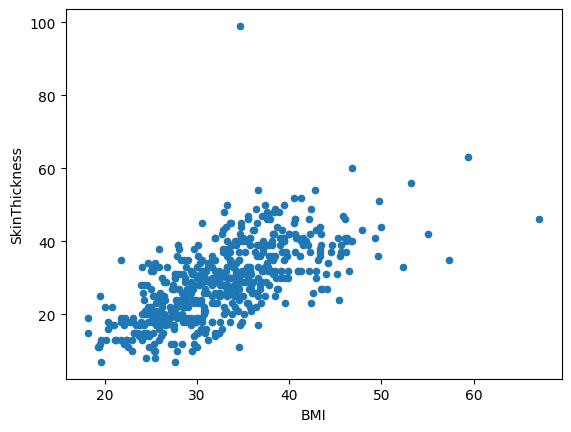

In [5]:
data.plot.scatter(x='BMI', y='SkinThickness');

13b. Create a scatter plot between `BMI` and `Glucose` (use Pandas or Seaborn to create the plot). 

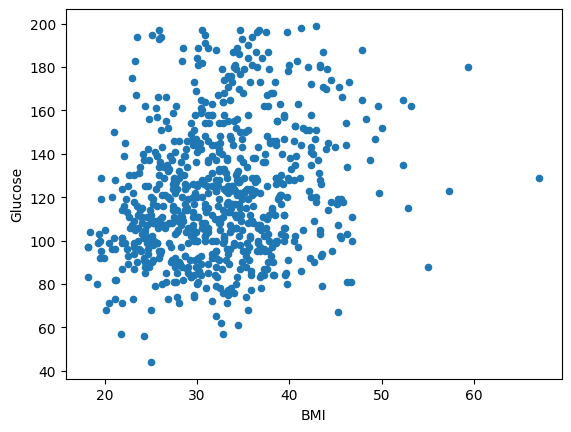

In [6]:
data.plot.scatter(x='BMI', y='Glucose');

13c. Based on a visual inspection of the two scatter plots, does `BMI` have a generally positive, negative or no association to `SkinThickness`? What about to `Glucose`?

BMI has a **positive association** with SkinThickness — as BMI increases, skin thickness tends to increase as well (the scatter plot trends upward). BMI has a **weak positive association** (or nearly no association) with Glucose — the points are more widely scattered with only a slight upward trend, suggesting the relationship between BMI and Glucose is much weaker than between BMI and SkinThickness.

13d. Are there any outliers in the two scatter plots? Note: there is some subjectivity in this, so be sure to explain your answer.

Yes, there appear to be outliers in both scatter plots. In the BMI vs SkinThickness plot, there are a few points with very high skin thickness values (above ~70) that are far from the main cluster. In the BMI vs Glucose plot, there are some points with very high BMI values (above ~60) that sit far to the right of the main body of data. These points are notable because they lie well outside the general range where most data points are concentrated.

14. Run the following cell.
    - Explain the code. Note: You need to explain what is happening at each dot. Hint: This is a complex one-liner; you can copy the original line and then delete stuff off the end to see what is happening at each step.
    - Interpret the results presented in the graph. Hint: the audience for your response is a regular person interested in diabetes; what are the takeaways from this graph?; go back to the data description to refresh yourself on what these data represent.

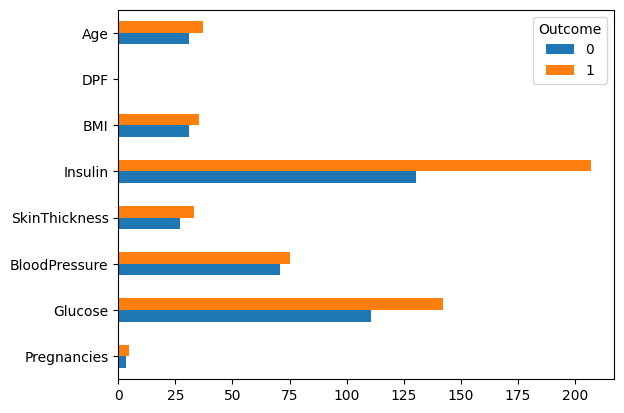

In [7]:
data.groupby('Outcome').mean().T.plot.barh();

**Code explanation:** This line chains several operations using dot notation:
1. `data` — starts with the full DataFrame
2. `.groupby('Outcome')` — groups all the rows by the `Outcome` column (0 = no diabetes, 1 = diabetes), creating two groups
3. `.mean()` — computes the average of every numeric column for each group, producing a DataFrame with 2 rows (one per outcome) and a column for each variable
4. `.T` — transposes (flips) the result so the variables become rows and the outcomes become columns, making it suitable for a horizontal bar chart
5. `.plot.barh()` — creates a horizontal bar chart comparing the two groups side by side for each variable

**Interpretation:** This graph compares the average values of each health measurement between women who have diabetes (Outcome = 1) and those who do not (Outcome = 0). The key takeaways are: women with diabetes tend to have higher average glucose levels, higher BMI, more pregnancies, higher insulin, higher blood pressure, greater skin thickness, and a higher diabetes pedigree function value compared to women without diabetes. They also tend to be older on average. These patterns suggest that these health indicators are associated with a higher likelihood of diabetes.

15. Histograms
    - Create a histogram for `BMI`; use `density=True` and include an `edgecolor` to help distinguish the bars (leave all other default settings; use Pandas or Seaborn to create the plot). 
        - Interpret the result.
    - Plot the histogram again, this time choosing the number of bins you think is best.
        - Explain why you chose that number of bins. The goal here is to have enough bins to get the full story, but not so many bins that there is a lot of noise.

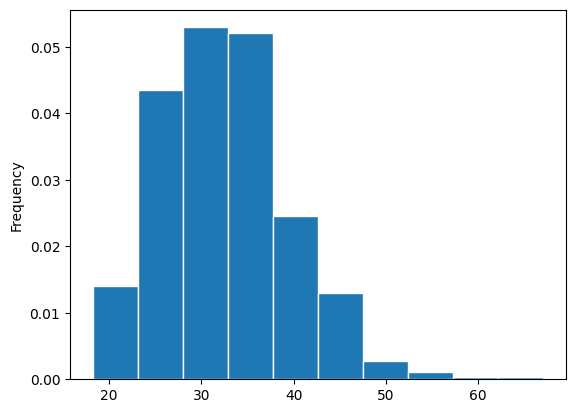

In [8]:
data['BMI'].plot.hist(density=True, edgecolor='white');

The histogram shows that BMI values are roughly normally distributed, centered around 32–33. The distribution is slightly skewed to the right, meaning there are a few individuals with very high BMI values (above 50). Most patients have a BMI between about 25 and 40.

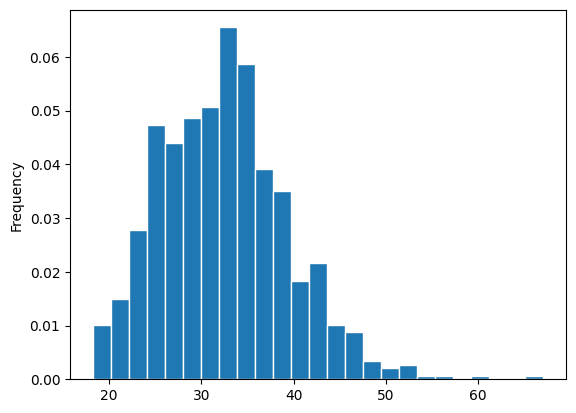

In [9]:
data['BMI'].plot.hist(density=True, edgecolor='white', bins=25);

I chose 25 bins because with the default number of bins (10), the histogram was too coarse and smoothed over some meaningful variation in the distribution. With 25 bins (each approximately 2 BMI units wide), the shape of the distribution is clear — you can see the peak, the slight right skew, and the thinning tails — without introducing excessive noise that would come from using too many bins (e.g., 50+).

16. The textbook authors feel strongly about using `density=True` when creating a histogram (your instructor is not so dogmatic on this matter). 
    - Create a `BMI` histogram with `density=False`, `edgecolor` and your preferred number of bins from the previous question
    - Discuss the shape of this histogram relative to the one from the previous question
    - What is the meaning of the y-axis in this question? What is the y-axis meaning in the previous question?

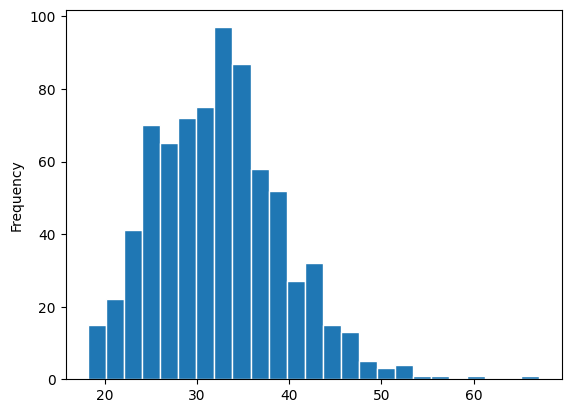

In [10]:
data['BMI'].plot.hist(density=False, edgecolor='white', bins=25);

The shape of this histogram is identical to the one from the previous question — the overall distribution pattern, skew, and relative bar heights are the same. The only difference is the y-axis scale.

In this histogram (`density=False`), the y-axis represents the **raw count** (frequency) of observations in each bin — how many patients fall into each BMI range. In the previous histogram (`density=True`), the y-axis represents **density** — the proportion of data in the bin divided by the bin width, so that the total area of all bars sums to 1.